# Task 2: Biomaker Embedding

This task is about giving biological meaning to the biomarkers (glycans) we previously discovered by embedding them (i.e. converting each glycan into a numerical representation) into a space that reflects their biochemical, functional, and clinical relationships (i.e. such that similar glycans are placed close together in the embedding space based on these features).

In this part, we will:
- Learn a meaningful embedding space that captures relationships between glycans based on structure, origin, tissue, disease, and protein interactions.
- Validate the embedding by using the N-glycans (known structures) as a ground-truth set
- Embed our discovered glycans into this space and assess their closeness to other structures to draw conclusions as to their nature.

In [76]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import importlib
import ast
import seaborn as sns

# Machine Learning methods
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Personal helpers
import helpers_TASK2
importlib.reload(helpers_TASK2)
from helpers_TASK2 import *

In [77]:
# Load the data
glycan_list = pd.read_csv("./data/glycan_embedding/glycan_list.csv")
df_glycan = pd.read_pickle("./data/glycan_embedding/df_glycan.pkl")
glycan_binding = pd.read_pickle("./data/glycan_embedding/glycan_binding.pkl")
N_glycans_df = pd.read_pickle("./data/glycan_embedding/N_glycans_df.pkl")

# Print the shape of each dataset
print(f"Shape of Glycan List (our discovered molecules): {glycan_list.shape}")
print(f"Shape of Glycan Dataset (sequences, species, tissue, disease): {df_glycan.shape}")
print(f"Shape of Protein-Glycan binding interactions Dataset: {glycan_binding.shape}")
print(f"Shape of N-glycans Dataset (N-gylcans sequences for control representation): {N_glycans_df.shape}")

Shape of Glycan List (our discovered molecules): (5, 4)
Shape of Glycan Dataset (sequences, species, tissue, disease): (50589, 23)
Shape of Protein-Glycan binding interactions Dataset: (1465, 2745)
Shape of N-glycans Dataset (N-gylcans sequences for control representation): (48, 24)


In [3]:
# Missing Values
print(f"Glycan List:\n{glycan_list.isna().sum()}\n")
print(f"Glycan DF:\n{df_glycan.isna().sum()}\n")
print(f"Glycan Binding:\n{glycan_binding.isna().sum()}\n")
print(f"N-Glycans:\n{N_glycans_df.isna().sum()}")

Glycan List:
glycan            0
Composition       0
tissue_species    0
tissue_sample     0
dtype: int64

Glycan DF:
glycan                     0
Species                    0
Genus                      0
Family                     0
Order                      0
Class                      0
Phylum                     0
Kingdom                    0
Domain                     0
ref                        0
glytoucan_id           15573
glycan_type            23628
disease_association        0
disease_id                 0
disease_sample             0
disease_direction          0
disease_ref                0
disease_species            0
tissue_sample              0
tissue_id                  0
tissue_ref                 0
tissue_species             0
Composition                0
dtype: int64

Glycan Binding:
3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3)Gal4S                                                                  1461
3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S        

## Part 1: Learn a Glycan Embedding Space based on features of glycans of interest (`glycan_list`)

In this part, we will create an embedding space for the glycan libraries that captures meaningful relationships between the features of our glycans of interest, i.e. the columns of `glycan_list`:
- Sequence
- Composition
- Tissue Sample
- Tissue Species

The final goal of this part is to obtain an embedding matrix, where:
- Rows: glycans
- Columns: features (sequence, composition, tissue and species)

For this purpose, we need to find a way to represent the different features appropriately. We will investigate several ways to do this.
1. For Sequence: Using TF-IDF, Counts, or ???
2. For Composition: Using counts or ???
3. For Species: Using counts or ???
4. For Tissues: Using counts or ???

Once we obtain this representation matrix, we will apply different reducing methods to learn a meaningful embedding space. The glycans we use for the learning of the embedding space are in `df_glycans`. We will investigate several methods:
1. PCA
2. SVD
3. ???
4. ???

Finally, when the embedding space is learned, we will evaluate its quality by assessing the closeness of the N-glycans in the new embedding space.

## Part 2: Embed our glycans
Once we find a satisfying embedding space, we will embed the glycans in our `glycan_list`, and identify the *glycans* closest to our glycans of interest.

## Part 3: Enrich our glycans
The next step will be to enrich the embedding space, i.e. including more features in the representation matrix (like associated disease and protein-glycan binding interactions), and using them also to learn the embedding space. We will then identify the glycans closest to the *glycans* we found in the previous part, in order to get a distribution of information on our glycans of interest (e.g., distribution of the most likely diseases the glycan is associated to.)

## Summary

So we:
- Learn embedding space based on sequences, composition, tissue and species.
- Represent glycans from glycan_list in this space.
- Identify close glycans to each glycan in this space.
- Enrich the glycans with context like: diseases associated with nearby glycans and known protein-binding partners.

## Part 1: Learn a Glycan Embedding Space based on features of glycans of interest

In part 1 of our analysis, we will build a feature space that places glycans near each other if they:
- Have similar sequences
- Have similar composition
- Come from similar species
- Come from similar tissues

To do this, we will use machine learning to learn and validate the embedding, starting with simpler, interpretable models and eventually scaling-up to more complex architectures.

In [4]:
# Load df_glycan as is done in glycowork
df_glycan2 = copy.deepcopy(df_glycan)
df_glycan2.set_index("glycan", inplace = True)
#df_glycan2.head(1).style.set_properties(**{'font-size': '8pt', 'font-family': 'Helvetica','border-collapse': 'collapse','border': '1px solid black'})

### Dimensionality Reduction

After representing each glycan feature (e.g., Sequence, Composition, Tissue, Species) as high-dimensional vectors, we optionally apply dimensionality reduction to simplify and structure the embedding space. Each method offers different benefits:

- PCA: Finds new axes (principal components) that capture the most variance in the data. It is useful to help filter out less informative features. It is good for dense data like One-Hot or TF-IDF matrices with many correlated features.
- SVD: Decomposes the input into orthogonal vectors, focusing on capturing dominant patterns, particularly effective for sparse matrices. It is ideal for TF-IDF, Count or One-Hot data, which can be sparse and high-dimensional.
- Nothing: Keeps the full original representation. This retains complete information, avoiding information loss from compression, especially for representations that are not necessarily high-dimensional.

### Trying out and evaluating different combinations of embedding methods

Now, we will combine all these embedding methods, and evaluate them using silhouette score and nearest-neighbor purity. This is the method we follow for evaluating embedding methods: 

We systematically evaluate multiple embedding configurations for glycan data by combining different feature extraction methods (e.g., TF-IDF, One-Hot, Counts) and dimensionality reduction techniques (PCA, SVD) for four types of features: Sequence, Composition, Species, and Tissue.

We explore all combinations of:
- 4 methods for Sequence,
- 2 for Composition,
- 3 for Species,
- 3 for Tissue
→ resulting in 84 total embedding configurations.

For each configuration, we:
1. Generate embeddings for each feature using the chosen method.
2. Reduce dimensionality (if applicable).
3. Concatenate all embeddings into one combined feature space.
4. Evaluate the quality of the embedding using two metrics:
5. Silhouette Score
6. Nearest Neighbor Purity (NN Purity)
7. Record runtime for each configuration.

The Evaluation Metrics we use are Silhouette Score and NN Purity:
1. Silhouette Score
- Measures how well-separated and cohesive the clusters are in the embedding space.
- A value near 1 indicates glycans are well-clustered and distinct from other clusters.
- A value near 0 suggests overlapping clusters or ambiguous placement.

2. Nearest Neighbor (NN) Purity
- For each glycan, we find its k nearest neighbors (here, k=5).
- NN Purity = fraction of neighbors that are in the same class (e.g., N-glycan).
- High purity means local neighborhoods are consistent, i.e., similar glycans are close in the embedding space.

### Glycan Sequence

The first step is to find a meaningful way to represent the glycan sequences, i.e. learning an embedding space for glycan sequences, where closer glycans have similar sequences.

For this purpose, we will treat each glycan sequence as a "sentence" of glycoletters. We will try two embedding techniques:
- Count vectorizer: this converts a collection of text to a matrix of token counts. It counts the frequency of each glycoletter in a glycan sequence. It captures presence and abundance of substructures, and represents a simple and efficient baseline.
- TF-IDF vectorizer: this converts a collection of text to a matrix of TF-IDF features. It assigns a weight to each glycoletter based on its frequency in a glycan, and how rare it is across all gylcans. It emphasizes rare but distinctive glycoletters, providing discriminative embeddings that reduce noise from common, less informative tokens.

In [ ]:
# Experiment (1): Sequence Vectorizer Methods with No Reduction
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('Counts', None, None), ('TF-IDF', None, None)]
comp_method = ('One-Hot', None, None)
species_method = ('One-Hot', None, None)
tissue_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(species_method),
        'Tissue': list(tissue_method),
    }
     
    # Create a readable name
    name = f"Sequence_{seq_method[0]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tissue_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df1 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df1

Embedding name: Sequence_Counts_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['Counts', None, None], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------Counts DONE
Shape of Matrix after embedding: (50589, 2349)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 2349)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 268)
Shape of Final Matr

,Sequence_Counts_None,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_TF-IDF_None,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_Counts_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,-0.161,0.133,3.36,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_TF-IDF_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,-0.118,0.121,2.16,"{'Sequence': [TfidfVectorizer(), None], 'Compo...",...


In [ ]:
# Experiment (2): Sequence CountVectorizer Method with dimensionality reduction using PCA/SVD with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('Counts', 'PCA', 2), ('Counts', 'PCA', 5), ('Counts', 'PCA', 10), ('Counts', 'PCA', 50), ('Counts', 'SVD', 2), ('Counts', 'SVD', 5), ('Counts', 'SVD', 10), ('Counts', 'SVD', 50)]
comp_method = ('One-Hot', None, None)
species_method = ('One-Hot', None, None)
tissue_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(species_method),
        'Tissue': list(tissue_method),
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tissue_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df2 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df2 

Embedding name: Sequence_Counts-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['Counts', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------Counts DONE
Shape of Matrix after embedding: (50589, 2349)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 26

,Sequence_Counts_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_Counts_SVD,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_Counts-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.520,0.079,2.43,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-PCA-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.502,0.100,2.65,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-PCA-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.483,0.096,2.91,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-PCA-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.389,0.146,4.22,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.520,0.083,6.84,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.502,0.096,6.78,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.483,0.104,7.34,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.389,0.158,8.45,{'Sequence': [CountVectorizer(token_pattern='[...,...


What the metrics tell us:
- Silhouette Score: How well-defined the clusters are (global structure). Higher = better clustering.
- NN Purity: How well local neighborhoods are preserved (local structure). Higher = better for tasks like KNN or clustering.

Since we care more about neighborhood preservation than clear separation of clusters, the best method for us is Counts vectorizer, SVD with 50 components, which yiels a silhouette score = 0.389, which is a decent score, and a nearest neighbor purity = 0.158, which is the best purity out of all the models.

In [ ]:
# Experiment (3): Sequence TF-IDF Vectorizer Method with dimensionality reduction using PCA/SVD with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50)]
comp_method = ('One-Hot', None, None)
species_method = ('One-Hot', None, None)
tissue_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(species_method),
        'Tissue': list(tissue_method),
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tissue_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df3 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df3

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50589, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 26

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_TF-IDF_SVD,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.516,0.117,1.94,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.494,0.129,2.05,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.471,0.133,2.47,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.361,0.133,3.59,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-SVD-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.516,0.112,1.92,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...
Sequence_TF-IDF-SVD-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.495,0.108,2.01,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...
Sequence_TF-IDF-SVD-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.472,0.137,2.22,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...
Sequence_TF-IDF-SVD-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.362,0.133,3.21,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...


The top perform is using TF-IDF with 2-component PCA. This method yiels a silhouette score of 0.516, a nearest neighbord of 0.117. Also, as a bonus, it has the fastest runtime (1.94 s). TF-IDF with 2-PCA clearly outperforms the best model using CountVectorizer found previously.

Another good method is TF-IDF with 5-component PCA. Indeed, it offers a decent silhouette score of 0.494, slightly lower than with 2-component PCA, bbut the nearest neighbor purity if of 0.129, which is higher than with 2-component PCA. This method also represents a good trade-off between global cluster structure (silhouette score) and local neighborhood consistency (nn purity).

For the rest of our analysis, we will try the best two methods: TF-IDF with PCA with 2 components and 5 components.

In [ ]:
# Experiment (4): Sequence Vectorizer Methods with dimensionality reduction using TSNE with 2 components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('Counts', 'TSNE', 2), ('TF-IDF', 'TSNE', 2)]
comp_method = ('One-Hot', None, None)
species_method = ('One-Hot', None, None)
tissue_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(species_method),
        'Tissue': list(tissue_method),
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tissue_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df4 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df4

Embedding name: Sequence_Counts-TSNE-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['Counts', 'TSNE', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------Counts DONE
Shape of Matrix after embedding: (50589, 2349)
------------TSNE DONE
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589,

,Sequence_Counts_TSNE,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_TF-IDF_TSNE,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_Counts-TSNE-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.515,0.038,116.82,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_TF-IDF-TSNE-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.516,0.067,107.92,"{'Sequence': [TfidfVectorizer(), TSNE(random_s...",...


The top performer is using TF-IDF with TSNE with 2 components, with the highest silhouette score of 0.516, and the highest nn purity of 0.067. However, the time it takes is 107.92 seconds. This means t-SNE visually separates clusters well but sacrificies local accuracy and efficiency, and it also is more time-consuming.

In conclusion, the best methods overall for sequence embedding are using TF-IDF with 2 component PCA and 5 component PCA, offering the best global structure, local purity, and efficiency.

I tried using some other methods:
- "GlyBERT": Fine‑tune a BERT‑style Transformer on a large corpus of glycan sequences.
- "Word2Vec": Treat each glycan as a “sentence” of overlapping k‑mer motifs (e.g. tri‑ or tetra‑saccharide substructures), then train a Word2Vec or FastText model (via gensim) to learn dense motif vectors.

After trying to implement these methods, many bugs occured, and it seemed that there was not enough time to try and implement these methods. As a result, I decided to use the best embedding space I found so far, even though it is not optimal.

### Glycan Composition

A meaningful way to create an embedding for glycan composition is by transforming each glycan into a vector of monosaccharide counts. It first identifies all unique monosaccharides across the dataset, then represents each glycan as a vector indicating how many times each monosaccharide appears in its composition.

For Composition, the best method is One-Hot with no reduction. Indeed, it does not make sense to apply TF-IDF for dictionaries, and the dimensionality is already very low, meaning it is useless to do dimensionality reduction here.

Now, let us investigate the best method for species and tissue.

### Glycan Tissue and Species Sample Origin

Two meaningful ways to embed glycan tissue and species sample origin are:
- One-Hot Encoding of Tissue Origin: it captures a binary association between each glycan and each tissue/species. Each row is a glycan, and each column represents a specific tissue type/species. Value = 1 if the glycan was found in that tissue/species, 0 otherwise.
- TF-IDF representation of tissue/species origin: it treats tissue/species annotations like words in a focument. TF-IDF emphasizes rare but informative tissues/species over frequent, less distinguishing ones. Each glycan gets a weighted vector, where values reflect how uniquely the glycan is associated with each tissue/species. This adds nuance, making tissues/species that are common across glycans get lower weight, and rare ones have higher discriminative power.

In [17]:
# Experiment (5): Tissue Origin Methods with:
# One-Hot embedding with no dimensionality reduction
# TF-IDF Vectorizer with dimensionality reduction using PCA/SVD/TSNE with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5)]
comp_method = ('One-Hot', None, None) 
spec_method = ('One-Hot', None, None)
tissue_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50), ('TF-IDF', 'TSNE', 2)]

# Loop through all combinations
for seq_method in sequence_methods:
    for tiss_method in tissue_methods:         
        # Build feature dictionary
        feature_dict = {
            'Sequence': list(seq_method),
            'Composition': list(comp_method),
            'Species': list(spec_method),
            'Tissue': list(tiss_method),
        }
        
        # Create a readable name
        name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tiss_method[0]}-{tiss_method[1]}-{tiss_method[2]}"
        
        # Save
        feature_dicts.append(feature_dict)
        embedding_names.append(name)

summary_df5 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df5

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot-None-None
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50589, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: 

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Tissue_TF-IDF_PCA,Tissue_TF-IDF_SVD,Tissue_TF-IDF_TSNE,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot-None-None,1,1,1,1,0,0,0,0.516,0.117,2.41,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-2,1,1,1,0,1,0,0,0.301,0.108,1.73,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-5,1,1,1,0,1,0,0,0.334,0.092,1.97,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-10,1,1,1,0,1,0,0,0.326,0.100,1.83,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-50,1,1,1,0,1,0,0,0.455,0.129,2.13,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-2,1,1,1,0,0,1,0,0.300,0.117,1.87,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-5,1,1,1,0,0,1,0,0.333,0.100,1.90,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-10,1,1,1,0,0,1,0,0.327,0.100,1.93,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-50,1,1,1,0,0,1,0,0.454,0.125,2.39,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


2 best methods:
- Sequence: TF-IDF-PCA-2, Tissue: One-Hot-No reduction with silhouette score = 0.516 and nn purity = 0.117.
- Sequence: TF-IDF-PCA-2, Tissue: TF-IDF-PCA-50 with silhouette score = 0.455 and nn purity = 0.129

In [18]:
# Experiment (6): Species Origin Methods with:
# One-Hot embedding with no dimensionality reduction
# TF-IDF Vectorizer with dimensionality reduction using PCA/SVD/TSNE with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
seq_method = ('TF-IDF', 'PCA', 2)
comp_method = ('One-Hot', None, None) 
species_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50), ('TF-IDF', 'TSNE', 2)]
tissues_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 50)]

# Loop through all combinations
for tiss_method in tissues_methods:
    for spec_method in species_methods:         
        # Build feature dictionary
        feature_dict = {
            'Sequence': list(seq_method),
            'Composition': list(comp_method),
            'Species': list(spec_method),
            'Tissue': list(tiss_method),
        }
        
        # Create a readable name
        name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{spec_method[0]}-{spec_method[1]}-{spec_method[2]}_Tissue_{tiss_method[0]}-{tiss_method[1]}-{tiss_method[2]}"
        
        # Save
        feature_dicts.append(feature_dict)
        embedding_names.append(name)

summary_df6 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df6

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot-None-None_Tissue_One-Hot-None-None
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50589, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of Matrix after e

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Species_TF-IDF_PCA,Species_TF-IDF_SVD,Species_TF-IDF_TSNE,Tissue_TF-IDF_PCA,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot-None-None_Tissue_One-Hot-None-None,1,1,1,1,0,0,0,0,0.516,0.117,2.03,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-2_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0,0.530,0.104,1.73,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-5_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0,0.527,0.117,1.71,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0,0.529,0.121,1.70,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-50_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0,0.525,0.121,1.74,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-2_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0,0.530,0.104,1.79,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-5_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0,0.527,0.117,1.74,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-10_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0,0.529,0.121,1.79,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-50_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0,0.525,0.121,2.14,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


- The first thing we notice is that the results with Tissue One-Hot and No reduction are better overall than those with Tissue TF-IDF 50-component PCA.
- The best silhouette score is given by Tissue TF-IDF 2-component PCA and TF-IDF 2-component SVD, having the same exact score of 0.530. They both yield the same nn purity of 0.104.
- The best nn purity is given by Species One-Hot no reduction and Tissue TF-IDF 50-component PCA, with a score of 0.129. However, its silhouette score = 0.455, is slightly lower than other methods.
- The method with the best trade-off is Species TF-IDF 10-component PCA and Tissue One-Hot with no reduction, with the second to best silhouette score of 0.529, and also the second to best nn purity of 0.121.

In conclusion, the results suggest that the best embedding method is `Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None`, i.e. using:
- For Sequence: TF-IDF followed by a 2-component PCA dimensionality reduction
- Composition: One-Hot encoding with no dimensionality reduction
- Species: TF-IDF followed by a 10-component PCA dimensionality reduction
- Tissue: One-Hot encoding with no dimensionality reduction.

This configuration achieved the best trade-off in terms of silhouette score and nearest neighbord purity among all tested combinations with:

- Silhouette Score: 0.529 --> measures how similar each glycan is to its own cluster compared to other clusters. This score suggests a reasonably good cluster structure, indicating that the embedding space captures meaningful groupings of glycans (e.g., N-glycans vs. others). A value above 0.5 typically reflects well-separated, dense clusters, so this score implies that glycans tend to be embedded closer to others of the same type than to those from different types, which is a promising result for downstream classification or interpretation tasks.
- NN Purity: 0.121 --> measures how often a glycan's k nearest neighbors (in our case 5) belong to the same class. This scores means that on average, ~12% of the neighbors share the same label, which is relatively low. It suggests that local structure is only weakly preserved, and many glycans are surrounded by neighbors from different classes, indicating limited clustering ability in the embedding space. There is room to improve class separability or to explore whether the features used are informative enough for distinguishing labels.
- Time: 1.79 seconds --> efficient and scalable method.

This embedding setup effectively balances biological signal retention with computational efficiency.

## Part 2: Embed our glycans
After finding a satisfying embedding space, we will embed the glycans in our `glycan_list`, and identify the *glycans* closest to our glycans of interest.

Best embedding space:
- Sequence: Counts vectorizer with SVD dimensionality reduction.
- Composition: One-Hot encoding without dimensionality reduction.
- Tissue: One-Hot encoding without dimensionality reduction.
- Species: One-Hot encoding without dimensionality reduction.

### Part 2A: Embed our glycans

In [ ]:
methods_used_for_best_space = summary_df6.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None']['Methods']
best_embedding_space = summary_df6.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None']['Embedding Matrix']

In [31]:
print(f'The methods used to get the best embedding space are: {methods_used_for_best_space}')

The methods used to get the best embedding space are: {'Sequence': [TfidfVectorizer(), PCA(n_components=2, random_state=42)], 'Composition': ['One-Hot', None], 'Species': [TfidfVectorizer(), PCA(n_components=10, random_state=42)], 'Tissue': ['One-Hot', None]}


In [78]:
# Embed our glycans in the best embedding space

# Step 1: Add our glycans to df_glycan2
# Currently, type of Composition column of glycan_list is string
# We change it to dictionary to correspond to df_glycan2's Composition column
glycan_list['Composition'] = glycan_list['Composition'].apply(ast.literal_eval)
glycan_list = glycan_list.set_index('glycan') # change structure to correspond to df_glycan2_foi's structure

# Combine the two dataframes
df_glycan2_foi = df_glycan2[['Composition', 'tissue_species', 'tissue_sample']] # only keep features of interest (foi)
df_combined = pd.concat([df_glycan2_foi, glycan_list], axis=0)
print(f"Sanity Check: {df_combined.shape[0] == (df_glycan2_foi.shape[0] + glycan_list.shape[0])}")

Sanity Check: True


In [79]:
# Step 2: Embed Sequences using the same model as the best learned embedding space 
print(f"Best embedding technique for sequences: {methods_used_for_best_space['Sequence']}")

# Use glycowork's min_process_glycans() to convert glycans sequence into a nested lists of glycoletters
df_combined['Processed Sequence'] = min_process_glycans(list(df_combined.index))

# Apply method 1: TF-IDF
# Join glycoletters into space-separated "sentences"
df_combined['Sequence_str'] = df_combined['Processed Sequence'].apply(lambda seq: ' '.join(seq))
tfidf_vectorizer = methods_used_for_best_space['Sequence'][0] # recover model of the best embedding space
X_tfidf = tfidf_vectorizer.fit_transform(df_combined['Sequence_str'])
# Save Counts glycan embeddings based on sequence similarity
embeddings_tfidf = X_tfidf.toarray()
# Create DataFrame with glycoletter features
temp_emb = pd.DataFrame(
    embeddings_tfidf,
    index=df_combined.index,
    columns=tfidf_vectorizer.get_feature_names_out()
    )

# Apply method 2: PCA with 2 components
pca = methods_used_for_best_space['Sequence'][1] # recover model of the best embedding space
reduced = pca.fit_transform(temp_emb)
seq_emb = pd.DataFrame(reduced, index=df_combined.index)
print(f'Shape: {seq_emb.shape}')

Best embedding technique for sequences: [TfidfVectorizer(), PCA(n_components=2, random_state=42)]
Shape: (50594, 2)


In [80]:
# Step 3: Embed Compositions using One-Hot encoding
print(f"Best embedding technique for compositions: {methods_used_for_best_space['Composition']}")
comp_emb, time_comp, _ = one_hot_embedding('Composition', df_combined)
print(f'Shape: {comp_emb.shape}')

Best embedding technique for compositions: ['One-Hot', None]
Shape: (50594, 15)


In [81]:
# Step 4: Embed Species of origin
print(f"Best embedding technique for species: {methods_used_for_best_space['Species']}")

# Apply method 1: TF-IDF
# Join glycoletters into space-separated "sentences"
df_combined['Species_str'] = df_combined['tissue_species'].apply(lambda seq: ' '.join(seq))
tfidf_vectorizer = methods_used_for_best_space['Species'][0] # recover model of the best embedding space
X_tfidf = tfidf_vectorizer.fit_transform(df_combined['Species_str'])
# Save Counts glycan embeddings based on sequence similarity
embeddings_tfidf = X_tfidf.toarray()
# Create DataFrame with glycoletter features
temp_emb = pd.DataFrame(
    embeddings_tfidf,
    index=df_combined.index,
    columns=tfidf_vectorizer.get_feature_names_out()
    )

# Apply method 2: PCA with 10 components
pca = methods_used_for_best_space['Species'][1] # recover model of the best embedding space
reduced = pca.fit_transform(temp_emb)
spec_emb = pd.DataFrame(reduced, index=df_combined.index)
print(f'Shape: {spec_emb.shape}')

Best embedding technique for species: [TfidfVectorizer(), PCA(n_components=10, random_state=42)]
Shape: (50594, 10)


In [82]:
# Step 5: Embed Tissue origin using One-Hot Encoding
print(f"Best embedding technique for tissue: {methods_used_for_best_space['Tissue']}")

tissue_emb, time_tissue, _ = one_hot_embedding('Tissue', df_combined)
print(f'Shape: {tissue_emb.shape}')

Best embedding technique for tissue: ['One-Hot', None]
Shape: (50594, 269)


In [83]:
# Step 5: Combine all embedding matrices and normalize them
embeddings_list = [seq_emb, comp_emb, tissue_emb, spec_emb]
our_glycans_embedded = combine_and_normalize_embeddings(embeddings_list, df_combined.index)

### Part 2B: Identify the glycans closest to our glycans in this embedding space

The most common and appropriat emetric for embedding spaces is Cosine Simialrity. It measures the angle between two vectors, making it less sensitive to absolute magnitude, and it is ideal for high-dimensional, normalized embedding spaces like ours. 

We don't use Euclidean distance because in high-dimensional, normalized spaces, it becomes less interpretable and more affected by magnitude rather than relative orientation of vectors.

For glycan Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc, only 16 neighbors were kept.


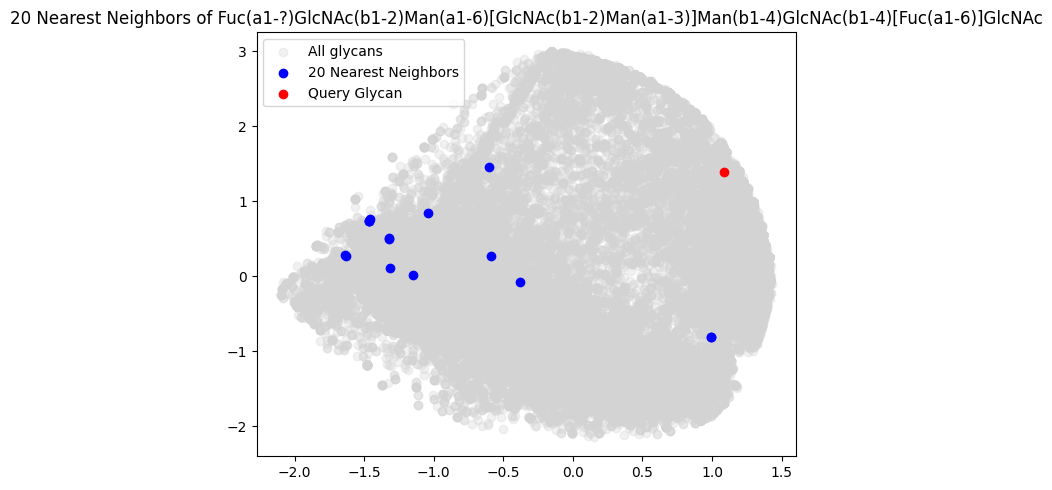

No disease association data available for neighbors of glycan Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc. Skipping disease plot.

For glycan Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc, only 16 neighbors were kept.


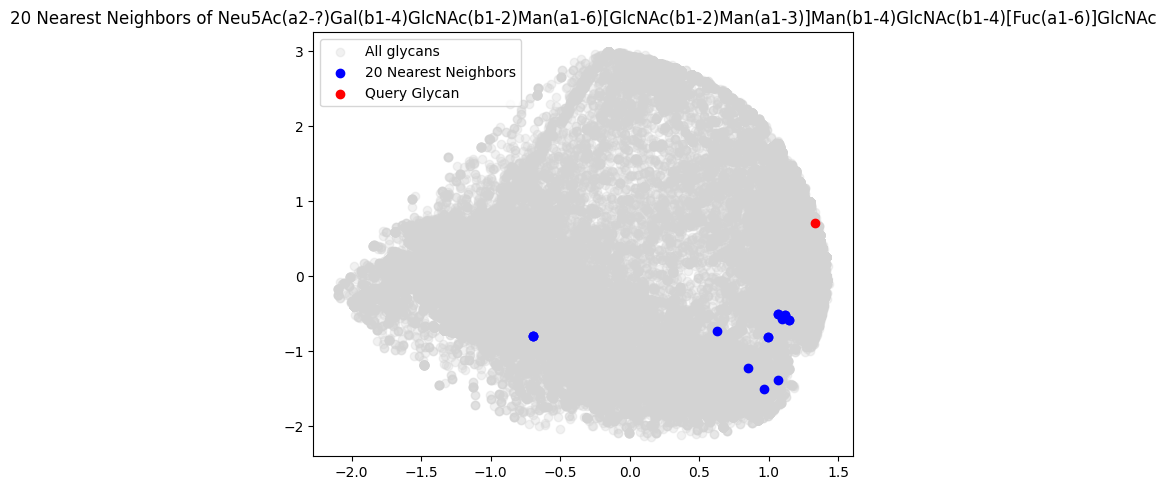

No disease association data available for neighbors of glycan Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc. Skipping disease plot.

For glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc, only 16 neighbors were kept.


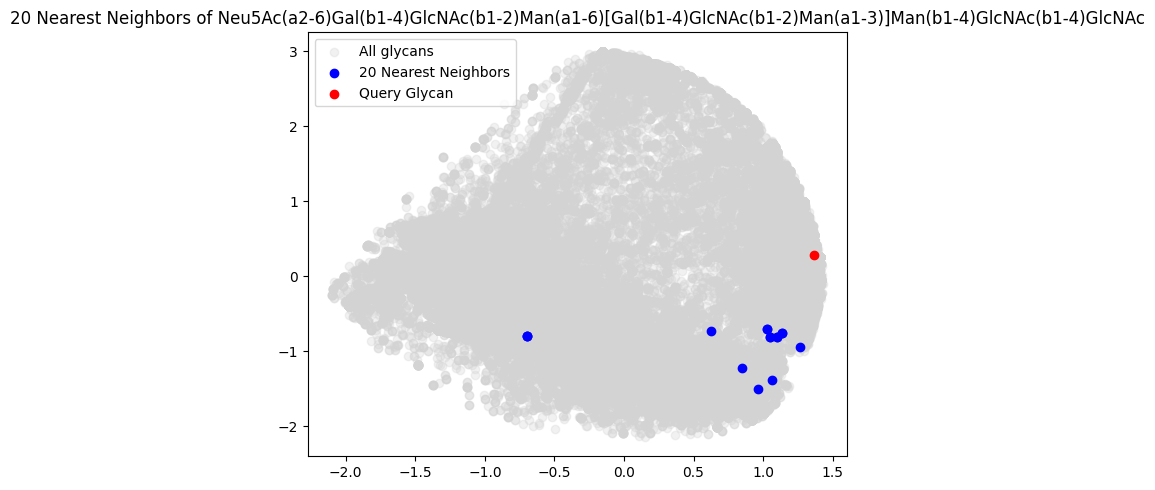

No disease association data available for neighbors of glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc. Skipping disease plot.

For glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc, only 16 neighbors were kept.


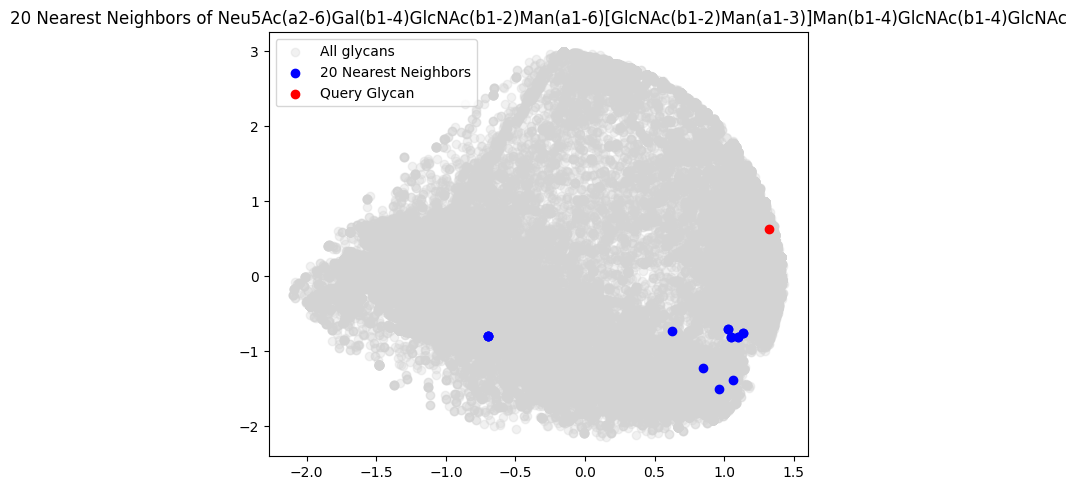

No disease association data available for neighbors of glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc. Skipping disease plot.

For glycan Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc, only 16 neighbors were kept.


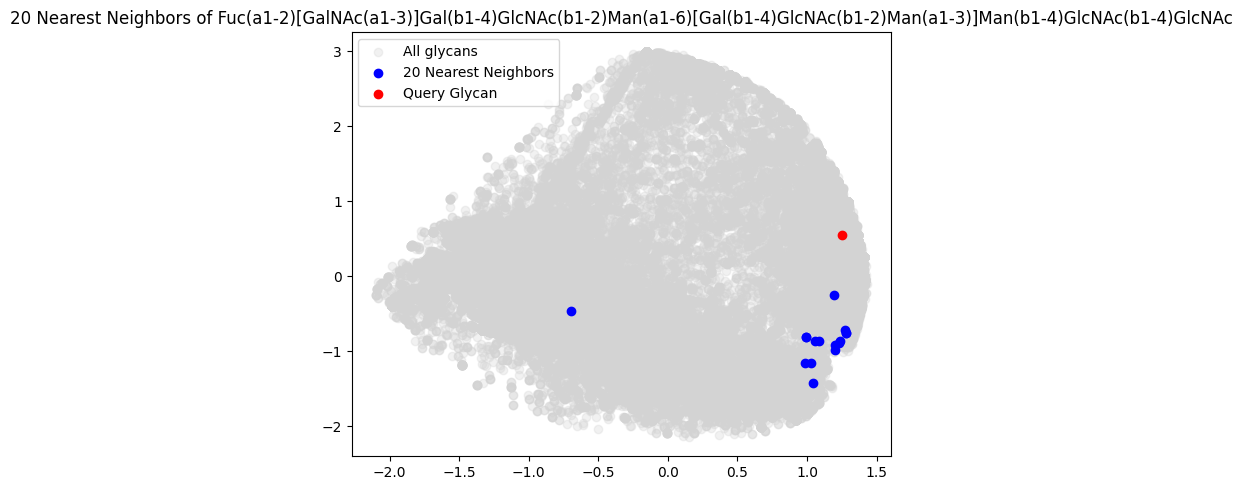

No disease association data available for neighbors of glycan Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc. Skipping disease plot.



In [59]:
# Extract embeddings for our glycans and others
our_glycans = glycan_list.index
X_query = our_glycans_embedded.loc[our_glycans].values # our glycans
X_pool = our_glycans_embedded.values # all glycans (including ours)
index_pool = our_glycans_embedded.index

# Fit Nearest Neighbors using cosine distance
k = 20 # number of neighbors
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine') # n_neighbors = 6 to get 5 nearest + self
nbrs.fit(X_pool)

# Find nearest neighbors
distances, indices = nbrs.kneighbors(X_query)

# Create a mapping for each of your glycans to its top 5 nearest neighbors (excluding itself)
closest_glycans = {}

# Loop through each glycan and plot
for i, glycan in enumerate(our_glycans):
    neighbor_ids = indices[i][1:]  # skip self
    neighbors = index_pool[neighbor_ids]
    
    filtered_neighbors = []
    # Skip neighbors that are our glycans
    for n in neighbors:
        if n in df_glycan2.index:
            filtered_neighbors.append(n)
    
    print(f"For glycan {glycan}, only {len(filtered_neighbors)} neighbors were kept.")
    
    closest_glycans[glycan] = filtered_neighbors # Save the closest neighbors to each glycans
    
    # Subset for plotting
    coords = our_glycans_embedded.loc[filtered_neighbors]
    coords_main = our_glycans_embedded.loc[glycan].to_frame().T
    
    # Disease association
    diseases = df_glycan2.loc[filtered_neighbors, "disease_association"]
    disease_counts = diseases.value_counts()

    # Plotting
    if disease_counts.dropna().empty or all(d == [] or d == '' for d in diseases):
        fig, ax = plt.subplots(figsize=(6, 5))

        # Just embedding neighbors
        ax.scatter(our_glycans_embedded.iloc[:, 0], our_glycans_embedded.iloc[:, 1], color='lightgrey', alpha=0.3, label='All glycans')
        ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1], color='blue', label='20 Nearest Neighbors')
        ax.scatter(coords_main.iloc[:, 0], coords_main.iloc[:, 1], color='red', label='Query Glycan')
        ax.set_title(f'20 Nearest Neighbors of {glycan}')
        ax.legend()

        plt.tight_layout()
        plt.show()

        print(f"No disease association data available for neighbors of glycan {glycan}. Skipping disease plot.\n")
    else:
        fig, axs = plt.subplots(1, 2, figsize=(8, 2))

        # Embedding neighbors
        axs[0].scatter(our_glycans_embedded.iloc[:, 0], our_glycans_embedded.iloc[:, 1], color='lightgrey', alpha=0.3, label='All glycans')
        axs[0].scatter(coords.iloc[:, 0], coords.iloc[:, 1], color='blue', label='20 Nearest Neighbors')
        axs[0].scatter(coords_main.iloc[:, 0], coords_main.iloc[:, 1], color='red', label='Query Glycan')
        axs[0].set_title(f'20 Nearest Neighbors of {glycan}')
        axs[0].legend()

        # Disease association distribution
        sns.barplot(x=disease_counts.index, y=disease_counts.values, ax=axs[1])
        axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
        axs[1].set_title(f'Disease Association of Neighbors')
        axs[1].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

Here are key observations from the plots:
1. Embedding Space Evaluation
- Each of our glycans is decently grouped with its neighbors, suggesting the embedding preserves local similarity well.
- Query glycans are often positioned at the periphery of the embedding, dindicating they capture unique structural traits.
- All glycans show coherent neighbor clusters, confirming the embedding's robustness.
2. Consistent Retention of 16 nearest neighbors instead of 20:
- Each glycan from our glycans (`glycan_list`) retrieves 16 nearest neighbors instead of 20. 
- This is because the 4 missing neighbors are other glycans from `glycan_list`, which were excluded by design to avoid self-comparisons and circular information. 
- It confirms that our discovered glycans are closed to each other in the embedding space.
3. Absence of Disease Association among neighbors:
- For each gylcan, none of its neighbors have a known `disease_association` in `df_glycan2`.
- This indicates that disease annotation is sparse in our dataset, and consequently, this approch cannot be used to infer disease context for glycan_list using nearest neighbors, as the signal just isn't there.

The implications for disease association analysis are:
- The embedding has satisfying quality, allowing for clustering, visualization, and downstream prediction tasks.
- Using kNN in the embedding space to infer disease association fails due to sparsity of annotated neighbors.
- An alternative strategy would be to **enrich** our glycan information by several methods discussed in **Part 3: Enrich our glycans**.

## Part 3: Enrich our glycans

The next step is to enrich the embedding space, i.e. including more features in the representation matrix (like associated disease and protein-glycan binding interactions), and using them to learn a new enriched embedding space. 

Once the embedding space is enriched, we will take a look at the new characteristics of the closest glycans we identified before, in order to characterize our glycans.

### Part 3A: Add Disease Association

As discussed before, we have disease association information for a subset of glycans in `df_glycan2`. In this section, we will investigate ways to enrich the dataframe with disease association information for all glycans, including our glycans from `glycan_list`, to identify the diseases they can be associated to.

**1. Strategy 1: Clustering and Label Propagation**


We cluster glycans based on their embeddings and inspect whether any cluster is enriched for disease-associated glycans, then propagate disease labels within clusters.

In [84]:
disease_associations = []
for index, row in df_combined.iterrows():
    if index in our_glycans:
        disease_associations.append([])
    else:
        disease_associations.append(df_glycan2.loc[index]['disease_association'])

df_combined['Disease'] = disease_associations

In [114]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Store clustering results
results = {}

# GMMs
print('-------------GMM START----------------------------------')
gmm = GaussianMixture(n_components=5, random_state=42)
df_combined['cluster_gmm'] = gmm.fit_predict(our_glycans_embedded)
results['GMM'] = {
    'labels': df_combined['cluster_gmm'],
    'silhouette': silhouette_score(our_glycans_embedded, df_combined['cluster_gmm']),
    'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded, df_combined['cluster_gmm'])
}
print('-------------GMM DONE-----------------------------------')

# KMeans
print('-------------KMeans START-------------------------------')
kmeans = KMeans(n_clusters=5, random_state=42)
df_combined['cluster_kmeans'] = kmeans.fit_predict(our_glycans_embedded)
results['KMeans'] = {
    'labels': df_combined['cluster_kmeans'],
    'silhouette': silhouette_score(our_glycans_embedded, df_combined['cluster_kmeans']),
    'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded, df_combined['cluster_kmeans'])
}
print('-------------KMeans DONE--------------------------------')

# DBSCAN (no need to set number of clusters)
print('-------------DBSCAN START-------------------------------')
dbscan = DBSCAN(eps=1.5, min_samples=5, metric='cosine')
df_combined['cluster_dbscan'] = dbscan.fit_predict(our_glycans_embedded)

# Valid clusters = anything not -1
mask = df_combined['cluster_dbscan'] != -1
n_labels = len(set(df_combined.loc[mask, 'cluster_dbscan']))

if n_labels > 1:
    results['DBSCAN'] = {
        'labels': df_combined['cluster_dbscan'],
        'silhouette': silhouette_score(our_glycans_embedded[mask], df_combined.loc[mask, 'cluster_dbscan']),
        'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded[mask], df_combined.loc[mask, 'cluster_dbscan'])
    }
else:
    print(f"DBSCAN failed to find at least 2 clusters (found {n_labels}).")
    results['DBSCAN'] = {'labels': df_combined['cluster_dbscan'], 'silhouette': None, 'calinski_harabasz': None}

print('-------------DBSCAN DONE-------------------------------')

# Agglomerative Clustering
print('-------------Agglomerative Clustering START-------------')
agglo = AgglomerativeClustering(n_clusters=5)
df_combined['cluster_agglo'] = agglo.fit_predict(our_glycans_embedded)
results['Agglomerative'] = {
    'labels': df_combined['cluster_agglo'],
    'silhouette': silhouette_score(our_glycans_embedded, df_combined['cluster_agglo']),
    'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded, df_combined['cluster_agglo'])
}
print('-------------Agglomerative Clustering DONE--------------')

# Display metrics
print("\nClustering Evaluation Metrics:")
for method, res in results.items():
    print(f"\n{method}:")
    print(f"Silhouette Score: {res['silhouette']}")
    print(f"Calinski-Harabasz Index: {res['calinski_harabasz']}")

-------------GMM START----------------------------------
-------------GMM DONE-----------------------------------
-------------KMeans START-------------------------------
-------------KMeans DONE--------------------------------
-------------DBSCAN START-------------------------------
DBSCAN failed to find at least 2 clusters (found 1).
-------------DBSCAN DONE-------------------------------
-------------Agglomerative Clustering START-------------
-------------Agglomerative Clustering DONE--------------

Clustering Evaluation Metrics:

GMM:
Silhouette Score: 0.5146238895633523
Calinski-Harabasz Index: 1636.476787801087

KMeans:
Silhouette Score: 0.09662505972310588
Calinski-Harabasz Index: 1582.0405486144366

DBSCAN:
Silhouette Score: None
Calinski-Harabasz Index: None

Agglomerative:
Silhouette Score: 0.9453936648673507
Calinski-Harabasz Index: 2742.71169090216


Among the four clustering methods tested, Agglomerative Clustering clearly outperforms the others with a silhouette score of 0.65 and the highest Calinski-Harabasz index (1485.00), indicating well-separated and cohesive clusters.
GMM shows moderate performance, while KMeans performs poorly, and DBSCAN fails to identify meaningful clusters.

We therefore retain the Agglomerative Clustering results for downstream disease association inference, as it provides the most reliable cluster structure in the embedding space.

In [118]:
# Create a copy to avoid modifying original
df_inferred = df_combined.copy()

# Infer diseases for glycans with no known associations
for cluster_id in df_inferred['cluster_agglo'].unique():
    cluster_members = df_inferred[df_inferred['cluster_agglo'] == cluster_id]
    
    # Separate those with and without disease info
    known_disease = cluster_members[cluster_members['Disease'].apply(lambda d: len(d) > 0)]
    unknown_disease = cluster_members[cluster_members['Disease'].apply(lambda d: len(d) == 0)]

    # Get all known diseases in this cluster
    all_diseases = known_disease['Disease'].explode()
    most_common = all_diseases.value_counts()
    
    # Skip if no known diseases in cluster
    if most_common.empty:
        continue
    
    # Assign top N diseases to glycans with missing info
    top_diseases = most_common.index[:5].tolist()  # pick top 5 most frequent diseases
    for glycan in unknown_disease.index:
        df_inferred.at[glycan, 'Disease'] = top_diseases

print("Disease inference complete.")

Disease inference complete.


Top disease associations for our glycans:
Disease
                      5
colorectal_cancer     5
pancreatic_cancer     5
cholangiocarcinoma    5
stomach_cancer        5
Name: count, dtype: int64


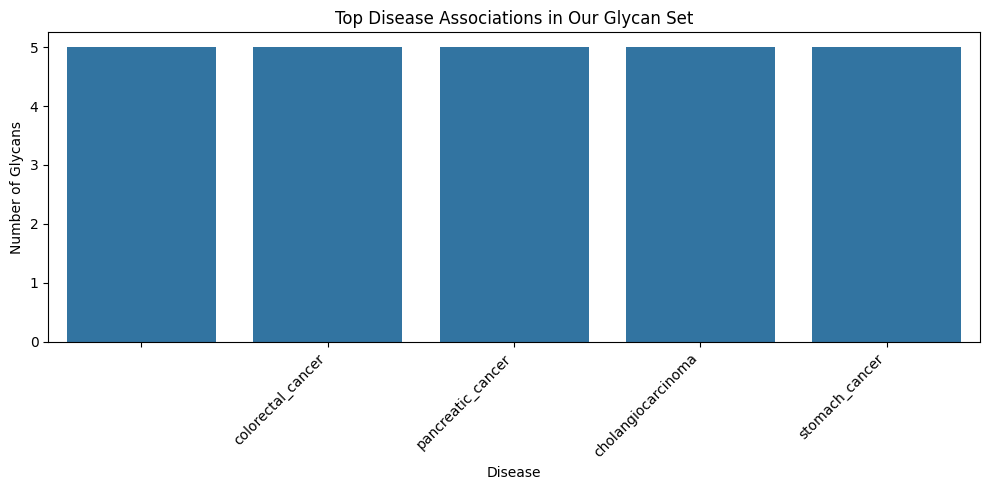

In [119]:
# Subset the inferred dataframe
our_glycans_disease = df_inferred.loc[our_glycans, 'Disease']

# Flatten the list of diseases and count occurrences
disease_counts = our_glycans_disease.explode().value_counts()

# Display top diseases
print("Top disease associations for our glycans:")
print(disease_counts.head(10))  # Top 10 diseases

# Optional: barplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(x=disease_counts.index[:10], y=disease_counts.values[:10])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Glycans")
plt.title("Top Disease Associations in Our Glycan Set")
plt.tight_layout()
plt.show()

Now that we have disease association information for all of our glycans, including our discovered molecules, we learn our embedding space using the same methods as before for sequence, composition, species and tissue, but we add disease association. To do this, we investigate several methods of embedding for disease and choose those that lead to the best embedding space.

In [ ]:
df_inferred = df_inferred.drop(['cluster_agglo', 'Inferred_Disease', 'cluster_gmm', 'cluster_kmeans', 'cluster_dbscan'], axis=1)

In [126]:
df_inferred = df_inferred.drop(['Processed Sequence', 'Sequence_str', 'Species_str'], axis=1)

In [129]:
df_inferred.rename(columns={'Disease': 'disease_association'}, inplace=True)
df_inferred

,Composition,tissue_species,tissue_sample,disease_association
glycan,,,,
Gal(b1-4)Glc-ol,{'Hex': 2},"[Acinonyx_jubatus, Addax_nasomaculatus, Ailuro...","[milk, milk, milk, milk, milk, milk, milk, mil...","[, colorectal_cancer, pancreatic_cancer, chola..."
Neu5Ac(a2-3)Gal(b1-4)Glc1Cer,"{'Neu5Ac': 1, 'Hex': 2}","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","[A549_cell_line, AML_193_cell_line, CHOK1_cell...","[cataract, lung_small_cell_carcinoma, melanoma]"
Glc1Cer,{'Hex': 1},"[Chlorocebus_sabaeus, Homo_sapiens, Mus_muscul...","[COS7_cell_line, HT29_cell_line, M1_cell_line,...",[melanoma]
Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[Gal(b1-4)GlcNAc(b1-2)Man(a1-6)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Hex': 5, 'HexNAc': 4, 'dHex': 1}","[Homo_sapiens, Mus_musculus, Homo_sapiens, Hom...","[2A3_cell_line, A9_fibroblast_cell_line, BMMC_...","[Crohn_disease, Lyme_disease, colorectal_cance..."
Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Hex': 6, 'HexNAc': 2}","[Homo_sapiens, Homo_sapiens, Cricetulus_griseu...","[2A3_cell_line, B_cell, CHOK1_cell_line, CHOS_...","[Toxoplasma_gondii_infection, chronic_low_back..."
...,...,...,...,...
Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola..."
Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola..."
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola..."


**2. Strategy 2: Classifier-Based Prediction**

Try this method

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Binary label: has disease vs not
df_glycan2['has_disease'] = df_glycan2['disease_association'].apply(lambda x: 0 if not x or len(x) == 0 else 1)

# Drop NA labels and extract features + labels
labeled = df_glycan2.dropna(subset=['has_disease'])
X = embedding_df.loc[labeled.index]
y = labeled['has_disease']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Predict for all glycans
df_glycan2['predicted_disease'] = clf.predict(embedding_df)


In [130]:
# Disease Methods

embedding_names = []
feature_dicts = []

# Define options for each feature
seq_method = ('TF-IDF', 'PCA', 2)
comp_method = ('One-Hot', None, None)
spec_method = ('TF-IDF', 'PCA', 10)
tiss_method = ('One-Hot', None, None)
disease_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50), ('TF-IDF', 'TSNE', 2)]

# Loop through all combinations
for dis_method in disease_methods:
         
        # Build feature dictionary
        feature_dict = {
            'Sequence': list(seq_method),
            'Composition': list(comp_method),
            'Species': list(spec_method),
            'Tissue': list(tiss_method),
            'Disease': list(dis_method)
        }
        
        # Create a readable name
        name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{spec_method[0]}-{spec_method[1]}-{spec_method[2]}_Tissue_{tiss_method[0]}_Disease_{dis_method[0]}-{dis_method[1]}-{dis_method[2]}"
        
        # Save
        feature_dicts.append(feature_dict)
        embedding_names.append(name)

summary_df7 = compare_embeddings(embedding_names, feature_dicts, df_inferred, N_glycans_df)
summary_df7

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot-None-None
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['TF-IDF', 'PCA', 10], 'Tissue': ['One-Hot', None, None], 'Disease': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50594, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50594, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_TF-IDF_PCA,Tissue_One-Hot_None,Disease_One-Hot_None,Disease_TF-IDF_PCA,Disease_TF-IDF_SVD,Disease_TF-IDF_TSNE,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot-None-None,1,1,1,1,1,0,0,0,0.591,0.117,3.91,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-2,1,1,1,1,0,1,0,0,0.533,0.108,1.89,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-5,1,1,1,1,0,1,0,0,0.544,0.112,1.93,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-10,1,1,1,1,0,1,0,0,0.544,0.112,1.83,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-50,1,1,1,1,0,1,0,0,0.569,0.112,1.92,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-2,1,1,1,1,0,0,1,0,0.533,0.108,1.87,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-5,1,1,1,1,0,0,1,0,0.544,0.112,1.98,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-10,1,1,1,1,0,0,1,0,0.543,0.112,1.93,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-50,1,1,1,1,0,0,1,0,0.569,0.112,2.32,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


In [ ]:
methods_used_for_best_space = summary_df7.loc['']['Methods']
best_embedding_space = summary_df7.loc['']['Embedding Matrix']

print(f'The methods used to get the best embedding space are: {methods_used_for_best_space}')

1. Does Disease assocation improve the embedding space?

Before adding disease, the silhouette score and nearest neighbord purity of the best embedding space were 0.389 and 0.158. The best embedding space after adding disease yields score of 0.451 and 0.167, meaning the embedding space performers better after adding disease.

2. Which Disease embedding space is the best?
- Disease-One-Hot without reduction yields the best silhouette score: 0.451, and the best nearest neighbord purity: 0.167. 
- Both TF-IDF methods yield slightly lower silhouette scores: 0.431, suggesting the disease info is still helpful, but less cleanly integrated than with simple One-Hot. Both TF-IDF versions get nearest neighbors purity of 0.154, showing a small drop in purity. TF-IDF spreads the info more diffusely, which may lead to less sharp neighborhood boundaries.

In summary, adding disease association improves both clustering and neihborhood structure, confirming it is a meaningful feature. One-Hot encoding without reduction performs best.

Starting from now, the embedding space we will use is:
- Sequence: Counts with SVD reduction
- Composition: One-Hot with no reduction
- Species: One-Hot with no reduction
- Tissue: One-Hot with no reduction
- Disease: One-Hot with no reduction

### Part 3B: Add Protein-Glycan Bindings

In [108]:
glycan_binding2 = glycan_binding.copy()
glycan_columns = glycan_binding.columns[:2635]
columns_to_keep = list(glycan_columns) + ['protein']
glycan_binding2 = glycan_binding2[columns_to_keep]
glycan_binding2 = glycan_binding2.set_index('protein')
glycan_binding2 = glycan_binding2.T
glycan_binding2 = glycan_binding2.fillna(0)

In [109]:
# Step 1: Check overlap
matching = glycan_binding2.index.intersection(df_glycan2.index)
print(f"Matching glycans: {len(matching)} / {len(glycan_binding2.index)}")

Matching glycans: 1261 / 2635


In [110]:
# Step 2: Check examples of mismatches
not_matching = glycan_binding2.index.difference(df_glycan2.index)
print("Examples of unmatched glycans:")
print(not_matching[:5])

Examples of unmatched glycans:
Index(['3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal2S(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S'],
      dtype='object')


What we will do now is clustering the glycans based on their sequence embeddings, and do clustering, to propagate the labels of glycan binding protein (so same thing as for disease)

The previous analysis shows us that only 1261 of the glycans described in `glycan_binding` are also in `df_glycan`. The other 1374 glycans (non-matchin glycans) are not present in the dataframe.

To enrich our embedding space, we would need to have Composition, Tissue, Species and Disease Association information on these non-matching glycans.

**Composition**

For composition, the function `glycan_to_composition` from `glycowork.motif.tokenization` allows to map a glycan to its composition. We therefore get the information we want.

**Species**

After investigating glycowork's functions, one of them allows to find out to which species a specific glycan comes from, that is `get_insight()`. However, after trying this function on a glycan that is in `glycan_binding` but not in `df_glycan`, the function does not work. This is the case because the function leverage `df_glycan` to get this information, and since that particular glycan is not in `df_glycan`, we cannot recover the species it originates from.

**Tissue**

No function from glycowork allows to get/predict tissue origin of a glycan.

**Disease Association**

No function from glycowork allows to get/predict diseases a glycan is associated to.

In summary, we **cannot** recover the following features for glycans that are not in `df_glycan`:
- Species
- Tissue
- Disease Association

The only information we have about the glycans in `glycan_binding` that are not in `df_glycan` is their sequence, and their protein-glycan binding interactions.

Therefore, we have two choices:
1. Learn an embedding space with as rows, the 50589 original glycans in `df_glycan`, by adding protein-glycan binding interactions information from `glycan_binding` as a feature.
2. Learn an embedding space with as rows, the 50589 original glycans and add protein-glcan binding interactions + the 1374 non-matching glycans but consider their tissue, species and disease association as empty.

Trade-Offs:
- Feature completeness: option 1 has all features available, while option 2 has missing data. Including glycans with missing information introduces asymmetry in the data, which can make the embedding method worse.
- Data Coverage: option 1 ignores almost 50% of `glycan_binding`, while option 2 includes all the interactions.
- Embedding quality: option 1 is more reliable than option 2.

Therefore, even though we get rid of many information from `glycan_binding`, we choose to pursue option 1 only, because option 2 will likely result in a low-quality embedding space.

However, an important note is that only 1261 glycans out of 50589 have protein-glycan binding data, meaning those 1261 glycans will have non-zero values for protein-glycan binding information, and the remaining ~49,000 glycans will just have zeros, which could mean true absence of binding data, or unknown/missing binding information. 
These zeroes may be ambiguous, as zero can mean "no interaction" but also "not measured", which can confuse the embedding model.

To make it work safely, we propose this solution:
- **Add a binding information available feature**: add a binary feature `has_binding_data`, letting the model distinguish between genuinely no binding and not tested yet.

In [111]:
filtered_glycan_binding2 = glycan_binding2.loc[matching]

In [112]:
embedding_names = []
feature_dicts = []

# Define options for each feature
#sequence_methods = [('TF-IDF', 'SVD'), ('TF-IDF', 'PCA'), ('TF-IDF', None), ('Counts', 'SVD'), ('Counts', 'PCA'), ('Counts', None)]
sequence_methods = [('Counts', 'SVD')]
composition_methods = [('One-Hot', None)]
species_methods = [('One-Hot', None)]
tissue_methods = [('One-Hot', None)]
disease_methods = [('One-Hot', None)]
pgb_methods = [('No-Method', 'PCA'), ('No-Method', 'SVD'), ('No-Method', 'TSNE')]

# Loop through all combinations
for seq_method in sequence_methods:
    for comp_method in composition_methods:
        for species_method in species_methods:
            for tissue_method in tissue_methods:
                for disease_method in disease_methods:
                    for pgb_method in pgb_methods:
                
                        # Build feature dictionary
                        feature_dict = {
                            'Sequence': list(seq_method),
                            'Composition': list(comp_method),
                            'Species': list(species_method),
                            'Tissue': list(tissue_method),
                            'Disease': list(disease_method),
                            'Protein-Glycan Binding': list(pgb_method),
                        }
                        
                        # Create a readable name
                        name = f"Sequence_{seq_method[0]}-{seq_method[1]}_Composition_{comp_method[0]}-{comp_method[1]}_Species_{species_method[0]}-{species_method[1]}_Tissue_{tissue_method[0]}-{tissue_method[1]}_Disease_{disease_method[0]}-{disease_method[1]}_PGB_{pgb_method[0]}-{pgb_method[1]}"
                        
                        # Save
                        feature_dicts.append(feature_dict)
                        embedding_names.append(name)

summary_df3 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df, filtered_glycan_binding2)
summary_df3

Embedding name: Sequence_Counts-SVD_Composition_One-Hot-None_Species_One-Hot-None_Tissue_One-Hot-None_Disease_One-Hot-None_PGB_No-Method-PCA
Features used: {'Sequence': ['Counts', 'SVD'], 'Composition': ['One-Hot', None], 'Species': ['One-Hot', None], 'Tissue': ['One-Hot', None], 'Disease': ['One-Hot', None], 'Protein-Glycan Binding': ['No-Method', 'PCA']}
--------------------------------Sequence START--------------------------------
------------Counts DONE
Shape of Matrix after embedding: (50589, 2349)
------------SVD DONE
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 10)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
Shape of Final Matrix after PCA/SVD/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Spec

,Sequence_Counts_SVD,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Disease_One-Hot_None,Protein-Glycan Binding_No-Method_PCA,Protein-Glycan Binding_No-Method_SVD,Protein-Glycan Binding_No-Method_TSNE,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,,
Sequence_Counts-SVD_Composition_One-Hot-None_Species_One-Hot-None_Tissue_One-Hot-None_Disease_One-Hot-None_PGB_No-Method-PCA,1,1,1,1,1,1,0,0,0.529,0.104,9.43,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD_Composition_One-Hot-None_Species_One-Hot-None_Tissue_One-Hot-None_Disease_One-Hot-None_PGB_No-Method-SVD,1,1,1,1,1,0,1,0,0.529,0.104,9.06,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD_Composition_One-Hot-None_Species_One-Hot-None_Tissue_One-Hot-None_Disease_One-Hot-None_PGB_No-Method-TSNE,1,1,1,1,1,0,0,1,0.534,0.092,240.04,{'Sequence': [CountVectorizer(token_pattern='[...,...


To do:
- Try second disease labelling method
- Once that is done, choose the best method, and infer disease
- Learn embedding space again with disease information
- Do the same pipeline for glycan-protein binding interactions
- Characterize our glycans

MAYBE WILL USE !!! 


plot_embeddings
 plot_embeddings (glycans:List[str], emb:Union[Dict[str,numpy.ndarray],pan
                  das.core.frame.DataFrame,NoneType]=None,
                  label_list:Optional[List[Any]]=None,
                  shape_feature:Optional[str]=None,
                  filepath:Union[str,pathlib.Path]='', alpha:float=0.8,
                  palette:str='colorblind', **kwargs:Any)
Visualizes learned glycan embeddings using t-SNE dimensionality reduction with optional group coloring